# COGS 108 - EDA Checkpoint

## Authors

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Team list and credits:
- Wuyue Huang: Project administration, Conceptualization, Software, Writing – review & editing
- Tiger Huang: Methodology, Experimental investigation, Software, Conceptualization
- Yining Ning: Background research, Experimental investigation, Software, Visualization
- Zhixi Guo: Software, Analysis, Visualization, Writing – original draft
- Yilei Wang: Software, Analysis, Experimental investigation, Writing – original draft

## Research Question

At the U.S. county level, are higher PM2.5 levels (Air Pollution: Particulate Matter raw value from the County Health Rankings 2025 analytic dataset) associated with higher adult COPD prevalence (%) and adult current asthma prevalence (%) (from CDC PLACES 2025 county estimates), after adjusting for adult smoking prevalence (%) and county-level covariates such as demographics, socioeconomic factors, urbanicity, and healthcare access?

## Background and Prior Work

It is an important topic in environmental and public health research for long-term exposure to
fine particulate matter (PM2.5). PM2.5 is defined as airborne particles with a diameter of 2.5
micrometers or smaller. These particles are small enough to be inhaled deep into the lungs. So
PM2.5 has been widely studied for its potential effects on respiratory and cardiovascular health.
Many studies focus on long-term exposure, which better represents chronic environmental
conditions, not short-term pollution events. 

Large-scale epidemiological research showed that populations living in areas with higher levels
of air pollution experienced higher mortality rates, even after accounting for other factors. This
work helped establish air pollution as a serious public health concern and motivated later studies
that focused more specifically on fine particulate matter, such as PM2.5. More recent review
papers summarize decades of research and conclude that long-term exposure to PM2.5 is
consistently associated with negative health outcomes.

At the county level, studying PM2.5 requires reliable exposure data that can be compared across
locations. CDC WONDER provides county-level PM2.5 estimates that are created by aggregating
gridded air pollution data to county boundaries, making it possible to calculate long-term
average PM2.5 exposure for each U.S. County. The CDC Environmental Public Health Tracking
program also identifies outdoor air quality as a key environmental factor linked to respiratory
health outcomes, supporting the relevance of PM2.5 for respiratory disease research.

Reliable county-level health outcome data are also necessary for this type of analysis. The CDC
PLACES project provides model-based estimates of chronic disease prevalence at the county
level, including adult chronic obstructive pulmonary disease (COPD) prevalence and adult current
asthma prevalence. These estimates are designed to support comparisons across counties and
are commonly used in public health research and planning.

Previous county-level studies have shown that PM2.5 can be meaningfully analyzed at this
geographic scale and related to population health outcomes. For example, a national study
examined associations between particulate matter pollution and life expectancy loss at the county
level, demonstrating that variation in PM2.5 across counties is large enough to be linked with
measurable differences in health outcomes. Building on this prior work, the current project
examines whether higher long-term PM2.5 exposure is associated with higher adult COPD and
current asthma prevalence at the U.S. County level.

Dockery DW, Pope CA III, Xu X, et al. (1993). An Association between Air Pollution and Mortality
in Six U.S. Cities. New England Journal of Medicine.
https://www.nejm.org/doi/full/10.1056/NEJM199312093292401

Pope CA III. (2020). Fine particulate air pollution and human mortality. Environment International .
https://www.sciencedirect.com/science/article/pii/S0013935119307212

U.S. Environmental Protection Agency. Particulate Matter (PM2.5) Trends.
https://www.epa.gov/air-trends/particulate-matter-pm25-trends

CDC WONDER. Outdoor Air Quality – Fine Particulate Matter (PM2.5).
https://wonder.cdc.gov/wonder/help/pm.html

Centers for Disease Control and Prevention. Air Quality (Outdoor) | Environmental Public Health
Tracking. https://www.cdc.gov/environmental-health-tracking/php/data-research/air-quality-
outdoor.html

## Hypothesis

We hypothesize that U.S. counties with higher PM2.5 levels (as measured by the County Health Rankings “Air Pollution: Particulate Matter” raw value) will have higher adult COPD prevalence and higher adult current asthma prevalence, even after controlling for adult smoking prevalence and county-level covariates (demographics, socioeconomic status, urbanicity, and healthcare access).

Fine particulate matter (PM2.5) can penetrate deep into the respiratory system and is plausibly linked to chronic respiratory conditions. In this project, we use county-level PM2.5 values from the County Health Rankings (Air Pollution: Particulate Matter raw value) and county-level respiratory outcome estimates (adult COPD prevalence and adult current asthma prevalence) from CDC PLACES. We test whether counties with higher PM2.5 also show higher respiratory disease burden at the population level, while adjusting for smoking and key county characteristics. Because all measures are aggregated to the county level, the analysis identifies ecological associations and does not by itself establish individual-level causality.

## Data

### Data overview

This EDA uses the processed county-level merged dataset created in the Data Checkpoint:

- `data/02-processed/final_merged_places_pm25.csv`
- Unit of analysis: one U.S. county (`fips`)
- Outcomes: adult COPD prevalence (`copd`), adult current asthma prevalence (`asthma`)
- Main exposure: annual mean PM2.5 concentration (`pm25`, µg/m³)
- Key confounder for this checkpoint: adult smoking prevalence (`smoking`)

The notebook below focuses on exploratory analysis quality: distribution checks, bivariate patterns, confounding context, and interpretable visual summaries. Because this is cross-sectional ecological data, we interpret findings as associations rather than causal effects.


### Dataset #1: CDC PLACES (2025 release)

County-level modeled prevalence estimates used in this checkpoint:
- Adult COPD prevalence (%)
- Adult current asthma prevalence (%)
- Adult smoking prevalence (%)

PLACES also provides confidence interval fields included in the merged dataset.


### Dataset #2: County Health Rankings (2025 analytic data)

County-level PM2.5 exposure measure:
- Air Pollution: Particulate Matter raw value (`pm25`, µg/m³)

This value is merged to PLACES by 5-digit county FIPS code (`fips`).


## Results

### Exploratory Data Analysis

In this EDA checkpoint, we analyze the final county-level merged dataset from `data/02-processed` to understand the structure of the data before final modeling. The analysis is organized in a step-by-step way: we first verify data quality and coverage, then describe the distributions of PM2.5 and respiratory outcomes, then examine bivariate relationships with both PM2.5 and smoking, and finally compare unadjusted versus smoking-adjusted linear models. We also include a state-level view to provide geographic context.

Because all variables are county-level aggregates in a cross-sectional dataset, the findings below should be interpreted as ecological associations rather than individual-level causal effects.


#### 1) Load Analysis Dataset and Verify Quality

To keep this notebook reproducible and efficient, we load only the final wrangled file (`final_merged_places_pm25.csv`) rather than re-running the full data wrangling pipeline. We then report basic coverage metrics, missingness rates, and summary statistics for the core variables used in this EDA.


In [ ]:
import os
from pathlib import Path
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.formula.api as smf
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
})


In [2]:
data_path = Path('data/02-processed/final_merged_places_pm25.csv')
assert data_path.exists(), f'Missing required file: {data_path}'

df = pd.read_csv(data_path)

core_cols = [
    'fips', 'LocationName', 'StateAbbr',
    'pm25', 'copd', 'asthma', 'smoking',
    'TotalPopulation', 'TotalPop18plus'
]

analysis = df[core_cols].copy()
analysis['fips'] = analysis['fips'].astype(str).str.zfill(5)
analysis_complete = analysis.dropna(subset=['pm25']).copy()

coverage = pd.DataFrame({
    'metric': [
        'Total counties in merged file',
        'Counties with non-missing PM2.5',
        'Counties dropped (missing PM2.5)',
        'Unique states represented',
    ],
    'value': [
        len(analysis),
        len(analysis_complete),
        len(analysis) - len(analysis_complete),
        analysis_complete['StateAbbr'].nunique(),
    ]
})

missing_rates = (
    analysis[['pm25', 'copd', 'asthma', 'smoking']]
    .isna()
    .mean()
    .rename('missing_fraction')
    .to_frame()
)

summary_stats = analysis_complete[['pm25', 'copd', 'asthma', 'smoking']].describe().T

display(coverage)
display(missing_rates)
display(summary_stats)


,metric,value
0,Total counties in merged file,2956
1,Counties with non-missing PM2.5,2873
2,Counties dropped (missing PM2.5),83
3,Unique states represented,48


,missing_fraction
pm25,0.028078
copd,0.000000
asthma,0.000000
smoking,0.000000


,count,mean,std,min,25%,50%,75%,max
pm25,2873.0,7.630352,2.062037,1.3,6.4,7.5,8.5,39.1
copd,2873.0,6.993282,1.535082,3.2,5.9,6.8,8.0,14.3
asthma,2873.0,10.718065,0.899395,7.9,10.1,10.7,11.3,15.1
smoking,2873.0,16.324330,3.459224,6.5,14.1,16.1,18.4,37.9


#### 2) Univariate Distributions

We begin with univariate plots to understand central tendency, spread, skewness, and potential outliers. This step is important because it helps us determine whether simple linear summaries are reasonable and whether any variable requires careful interpretation due to strong asymmetry.


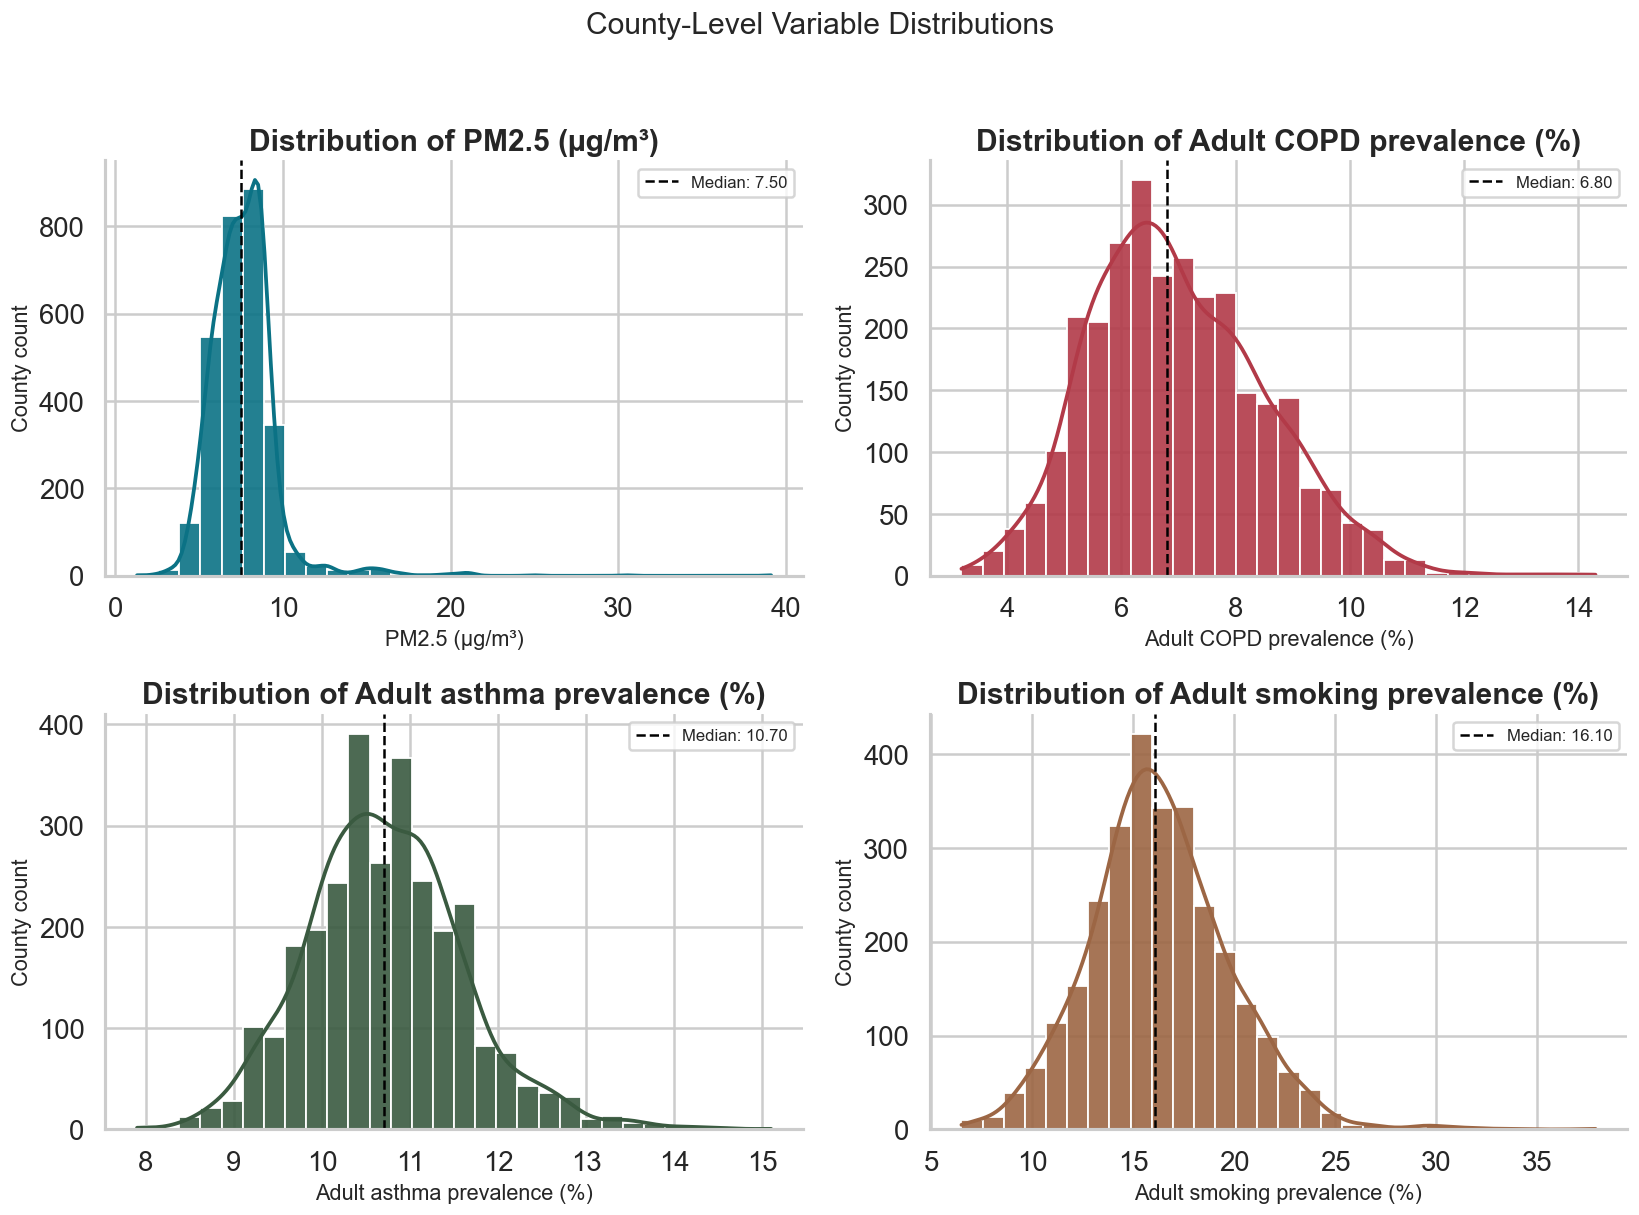

In [3]:
plot_specs = [
    ('pm25', 'PM2.5 (µg/m³)', '#0b7285'),
    ('copd', 'Adult COPD prevalence (%)', '#b23a48'),
    ('asthma', 'Adult asthma prevalence (%)', '#3a5a40'),
    ('smoking', 'Adult smoking prevalence (%)', '#9c6644'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (col, label, color) in zip(axes.flatten(), plot_specs):
    sns.histplot(
        analysis_complete[col],
        bins=30,
        kde=True,
        color=color,
        edgecolor='white',
        alpha=0.9,
        ax=ax,
    )
    med = analysis_complete[col].median()
    ax.axvline(med, color='black', linestyle='--', linewidth=1.5, label=f'Median: {med:.2f}')
    ax.set_title(f'Distribution of {label}')
    ax.set_xlabel(label)
    ax.set_ylabel('County count')
    ax.legend(frameon=True, fontsize=10)

plt.suptitle('County-Level Variable Distributions', y=1.02, fontsize=18)
plt.tight_layout()
plt.show()


The distribution plots show that county-level PM2.5 is right-skewed: most counties are concentrated in lower PM2.5 ranges, with a smaller set of counties in a high-exposure tail. COPD and smoking exhibit broader dispersion than asthma, indicating stronger county-to-county heterogeneity for those measures. Overall, the observed ranges are plausible for county-level public health indicators and support the use of this dataset for exploratory modeling.


#### 3) PM2.5 vs Respiratory Outcomes

Next, we evaluate direct bivariate patterns between PM2.5 and each respiratory outcome using scatterplots with fitted linear trend lines. This provides a first-pass visual check of whether higher PM2.5 counties also tend to have higher respiratory burden.


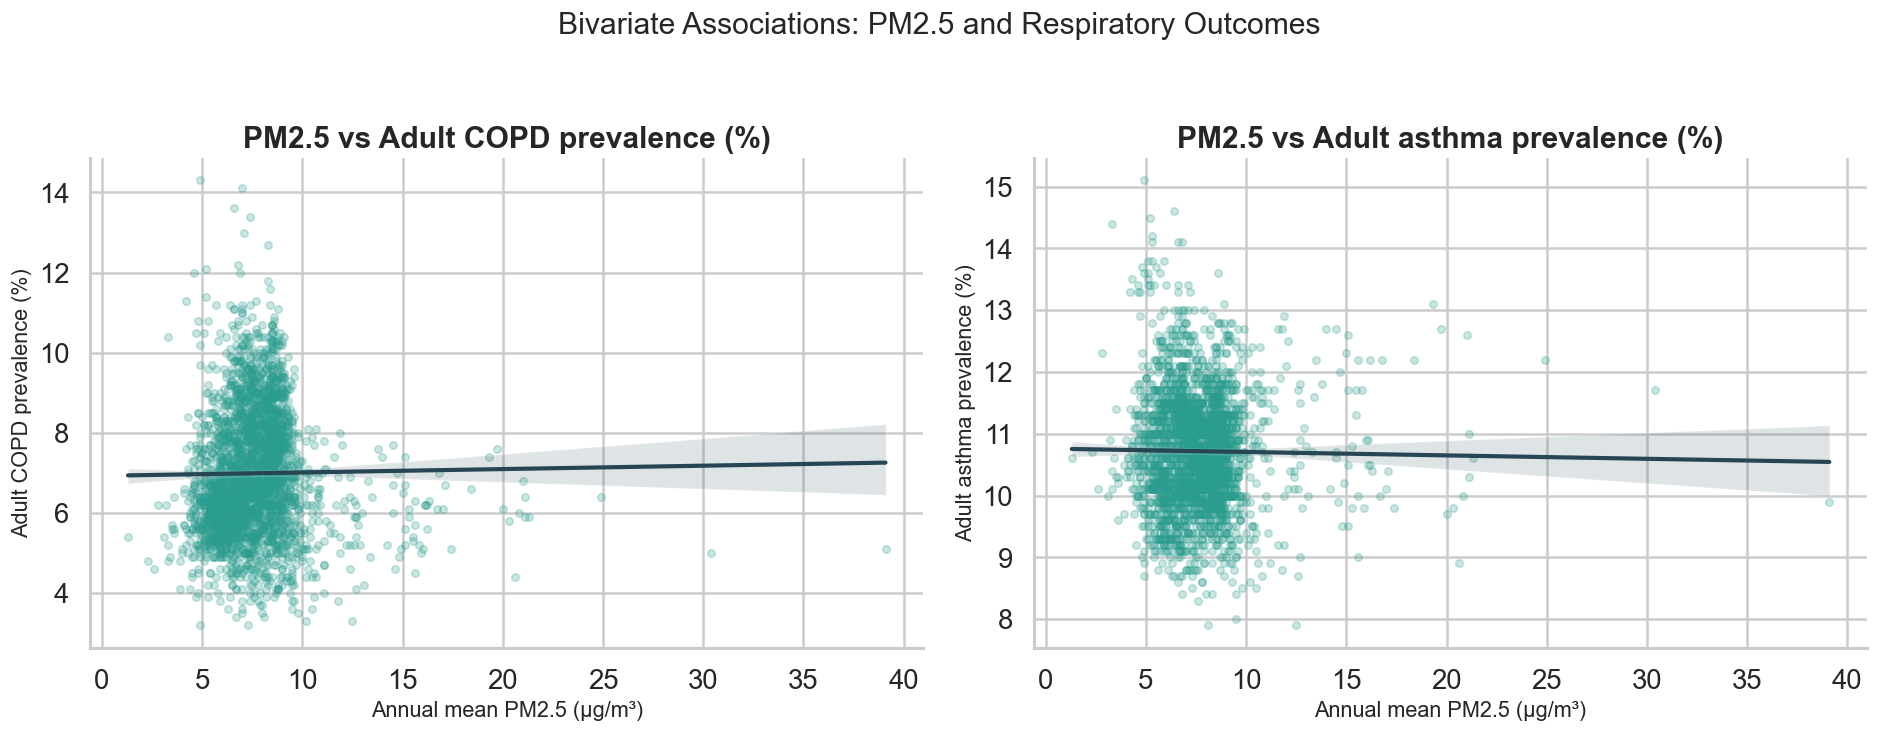

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

outcomes = [
    ('copd', 'Adult COPD prevalence (%)'),
    ('asthma', 'Adult asthma prevalence (%)'),
]

for ax, (y, y_label) in zip(axes, outcomes):
    sns.regplot(
        data=analysis_complete,
        x='pm25',
        y=y,
        scatter_kws={'alpha': 0.25, 's': 20, 'color': '#2a9d8f'},
        line_kws={'color': '#264653', 'linewidth': 2.5},
        ax=ax,
    )
    ax.set_title(f'PM2.5 vs {y_label}')
    ax.set_xlabel('Annual mean PM2.5 (µg/m³)')
    ax.set_ylabel(y_label)

plt.suptitle('Bivariate Associations: PM2.5 and Respiratory Outcomes', y=1.03, fontsize=18)
plt.tight_layout()
plt.show()


In the unadjusted bivariate plots, the PM2.5-COPD trend is slightly positive but weak, with substantial vertical dispersion. For asthma, the PM2.5 trend is close to flat in the unadjusted view. These figures suggest that PM2.5 alone explains only a small portion of between-county variation, and that additional factors are likely important.


#### 4) Smoking vs Respiratory Outcomes

Because smoking is a major respiratory risk factor and a likely confounder in this project, we compare smoking-outcome patterns directly with the PM2.5-outcome patterns.


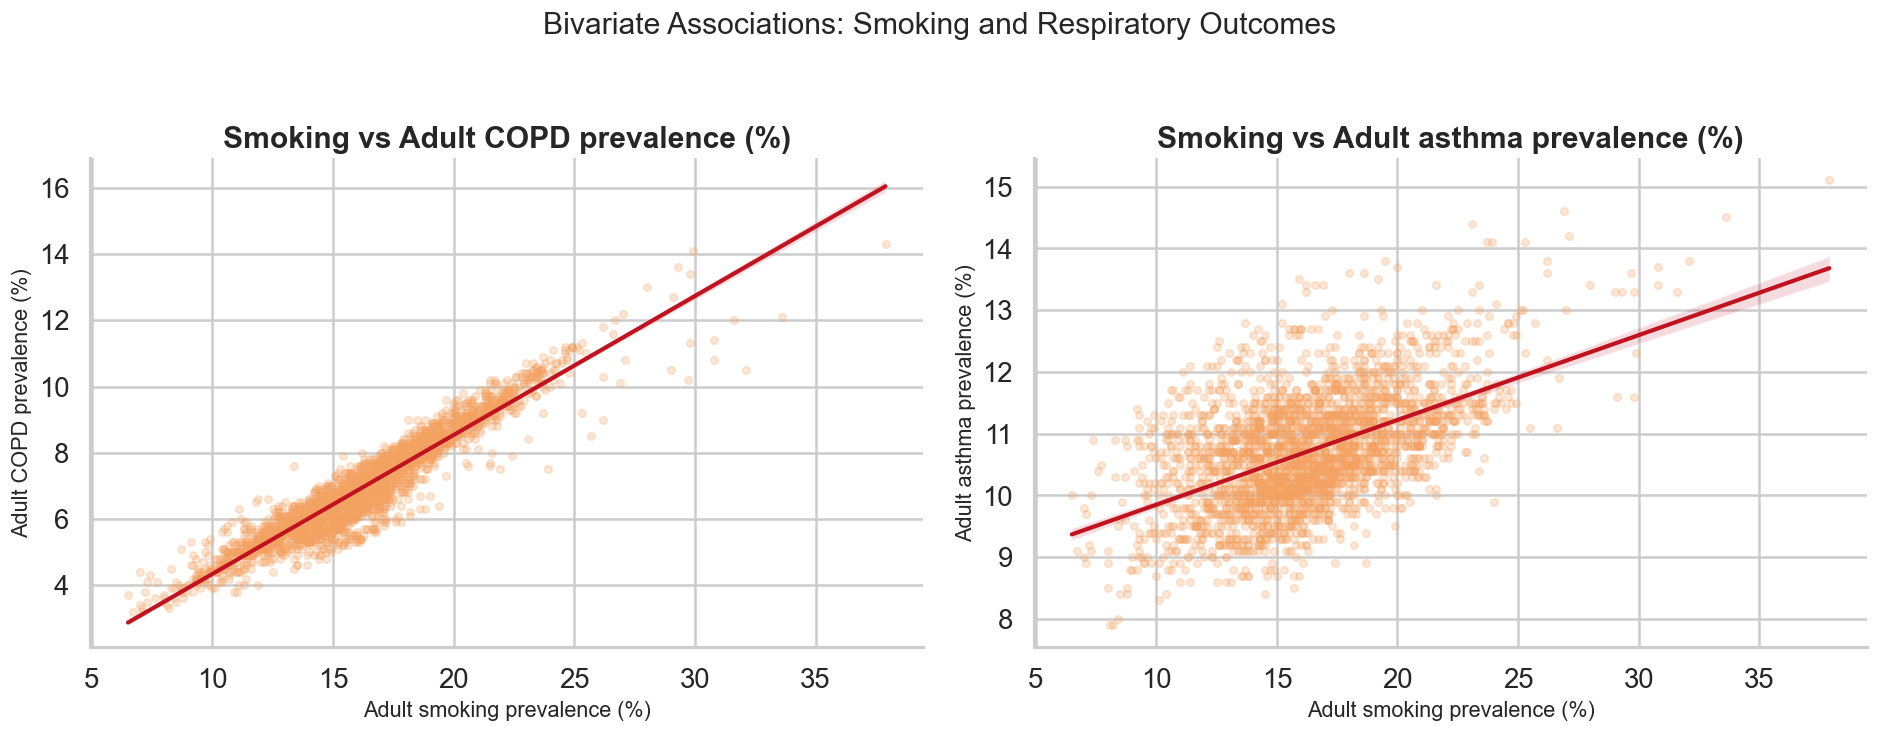

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

outcomes = [
    ('copd', 'Adult COPD prevalence (%)'),
    ('asthma', 'Adult asthma prevalence (%)'),
]

for ax, (y, y_label) in zip(axes, outcomes):
    sns.regplot(
        data=analysis_complete,
        x='smoking',
        y=y,
        scatter_kws={'alpha': 0.25, 's': 20, 'color': '#f4a261'},
        line_kws={'color': '#c1121f', 'linewidth': 2.5},
        ax=ax,
    )
    ax.set_title(f'Smoking vs {y_label}')
    ax.set_xlabel('Adult smoking prevalence (%)')
    ax.set_ylabel(y_label)

plt.suptitle('Bivariate Associations: Smoking and Respiratory Outcomes', y=1.03, fontsize=18)
plt.tight_layout()
plt.show()


Smoking shows a much clearer positive relationship with COPD than PM2.5 does, and it also shows a positive relationship with asthma (though more moderate). This contrast reinforces the need to treat smoking as a core adjustment variable before interpreting any PM2.5 coefficients in regression models.


#### 5) Correlation Structure

To complement the plots, we compute both Pearson and Spearman correlations among PM2.5, smoking, COPD, and asthma. Reporting both metrics helps us compare linear association (Pearson) with rank-based monotonic association (Spearman).


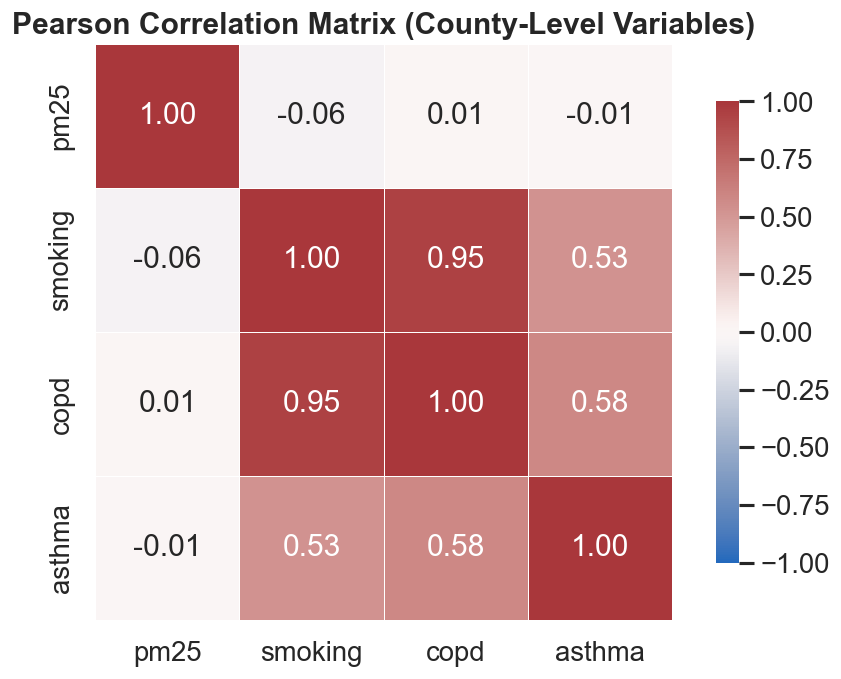

,Predictor,Outcome,Pearson r,Pearson p,Spearman rho,Spearman p
0,pm25,copd,0.0113,0.5443,0.1331,0.0000
1,pm25,asthma,-0.0127,0.4966,-0.0079,0.6719
2,smoking,copd,0.9457,0.0000,0.9376,0.0000
3,smoking,asthma,0.5280,0.0000,0.4746,0.0000


In [6]:
corr_vars = ['pm25', 'smoking', 'copd', 'asthma']
pearson_corr = analysis_complete[corr_vars].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(
    pearson_corr,
    annot=True,
    fmt='.2f',
    cmap='vlag',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)
plt.title('Pearson Correlation Matrix (County-Level Variables)')
plt.tight_layout()
plt.show()

pairs = [
    ('pm25', 'copd'),
    ('pm25', 'asthma'),
    ('smoking', 'copd'),
    ('smoking', 'asthma'),
]

rows = []
for x, y in pairs:
    r, p = stats.pearsonr(analysis_complete[x], analysis_complete[y])
    rho, p_s = stats.spearmanr(analysis_complete[x], analysis_complete[y])
    rows.append({
        'Predictor': x,
        'Outcome': y,
        'Pearson r': r,
        'Pearson p': p,
        'Spearman rho': rho,
        'Spearman p': p_s,
    })

corr_tests = pd.DataFrame(rows)

display(corr_tests.round(4))


The correlation table indicates near-zero Pearson correlations between PM2.5 and both COPD/asthma in this cross-section, while the PM2.5-COPD Spearman correlation is modestly positive, suggesting a weak rank-based pattern that is not strongly linear. In contrast, smoking has the strongest association with COPD and a moderate positive association with asthma. Taken together, these results are consistent with the bivariate plots: unadjusted PM2.5 effects are small relative to smoking at the county level.


#### 6) PM2.5 Quartile Comparison

We then compare outcomes across PM2.5 quartiles. This is a useful robustness-oriented descriptive check because quartile summaries are less sensitive to extreme values than a single fitted line.


,pm25_quartile,counties,pm25_mean,smoking_mean,copd_mean,asthma_mean
0,Q1 (Lowest),725,5.572,15.655,6.504,10.747
1,Q2,732,7.009,16.789,7.189,10.772
2,Q3,699,8.100,16.985,7.366,10.661
3,Q4 (Highest),717,9.887,15.883,6.926,10.690


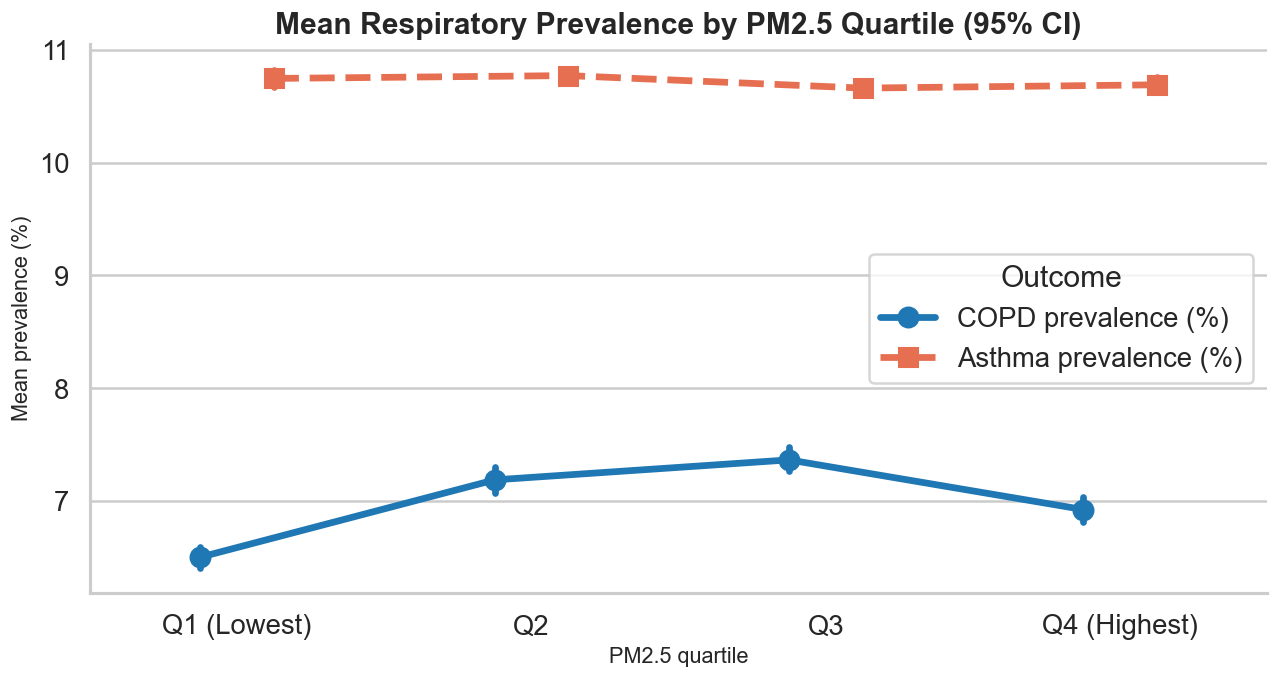

In [7]:
analysis_complete['pm25_quartile'] = pd.qcut(
    analysis_complete['pm25'],
    q=4,
    labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
)

quartile_summary = (
    analysis_complete
    .groupby('pm25_quartile', observed=True)
    .agg(
        counties=('fips', 'nunique'),
        pm25_mean=('pm25', 'mean'),
        smoking_mean=('smoking', 'mean'),
        copd_mean=('copd', 'mean'),
        asthma_mean=('asthma', 'mean')
    )
    .reset_index()
)

display(quartile_summary.round(3))

plot_df = analysis_complete.melt(
    id_vars='pm25_quartile',
    value_vars=['copd', 'asthma'],
    var_name='Outcome',
    value_name='Prevalence'
)

plot_df['Outcome'] = plot_df['Outcome'].map({
    'copd': 'COPD prevalence (%)',
    'asthma': 'Asthma prevalence (%)'
})

plt.figure(figsize=(11, 6))
sns.pointplot(
    data=plot_df,
    x='pm25_quartile',
    y='Prevalence',
    hue='Outcome',
    estimator=np.mean,
    errorbar=('ci', 95),
    dodge=0.25,
    markers=['o', 's'],
    linestyles=['-', '--'],
    palette=['#1f77b4', '#e76f51'],
)
plt.title('Mean Respiratory Prevalence by PM2.5 Quartile (95% CI)')
plt.xlabel('PM2.5 quartile')
plt.ylabel('Mean prevalence (%)')
plt.legend(title='Outcome', frameon=True)
plt.tight_layout()
plt.show()


Across quartiles, mean COPD increases from Q1 to Q3 and then declines in Q4, so the pattern is not strictly monotonic. Mean asthma remains relatively stable across PM2.5 quartiles. We also observe differences in smoking prevalence across PM2.5 quartiles, which indicates that crude quartile comparisons still combine exposure differences with confounding structure.


#### 7) Unadjusted vs Smoking-Adjusted OLS Models

Finally, we fit simple exploratory OLS models to compare PM2.5 coefficients before and after adding smoking. These models are intended for descriptive interpretation and coefficient sensitivity checks, not for causal inference.


In [8]:
m_copd_unadj = smf.ols('copd ~ pm25', data=analysis_complete).fit()
m_copd_adj = smf.ols('copd ~ pm25 + smoking', data=analysis_complete).fit()
m_asthma_unadj = smf.ols('asthma ~ pm25', data=analysis_complete).fit()
m_asthma_adj = smf.ols('asthma ~ pm25 + smoking', data=analysis_complete).fit()

def collect_terms(model, outcome, spec, terms):
    rows = []
    for term in terms:
        if term in model.params.index:
            ci_low, ci_high = model.conf_int().loc[term]
            rows.append({
                'Outcome': outcome,
                'Model': spec,
                'Term': term,
                'Coef': model.params[term],
                'SE': model.bse[term],
                'p_value': model.pvalues[term],
                'CI_low': ci_low,
                'CI_high': ci_high,
                'R_squared': model.rsquared,
                'N': int(model.nobs),
            })
    return rows

model_rows = []
model_rows += collect_terms(m_copd_unadj, 'copd', 'Unadjusted', ['pm25'])
model_rows += collect_terms(m_copd_adj, 'copd', 'Adjusted (+smoking)', ['pm25', 'smoking'])
model_rows += collect_terms(m_asthma_unadj, 'asthma', 'Unadjusted', ['pm25'])
model_rows += collect_terms(m_asthma_adj, 'asthma', 'Adjusted (+smoking)', ['pm25', 'smoking'])

model_table = pd.DataFrame(model_rows)
display(model_table.round(4))


,Outcome,Model,Term,Coef,SE,p_value,CI_low,CI_high,R_squared,N
0,copd,Unadjusted,pm25,0.0084,0.0139,0.5443,-0.0188,0.0357,0.0001,2873
1,copd,Adjusted (+smoking),pm25,0.0524,0.0044,0.0000,0.0437,0.0610,0.8992,2873
2,copd,Adjusted (+smoking),smoking,0.4216,0.0026,0.0000,0.4164,0.4268,0.8992,2873
3,asthma,Unadjusted,pm25,-0.0055,0.0081,0.4966,-0.0215,0.0104,0.0002,2873
4,asthma,Adjusted (+smoking),pm25,0.0088,0.0069,0.2033,-0.0048,0.0224,0.2792,2873
5,asthma,Adjusted (+smoking),smoking,0.1376,0.0041,0.0000,0.1295,0.1457,0.2792,2873


In unadjusted models, PM2.5 coefficients are small and not statistically distinguishable from zero for either COPD or asthma. After adjusting for smoking, the PM2.5 coefficient becomes clearly positive for COPD, while it remains weak/non-significant for asthma. Smoking itself is a strong positive predictor in both adjusted models, especially for COPD, which is consistent with the earlier correlation and scatterplot evidence.


#### 8) State-Level Context

To add geographic context, we aggregate to state means (with a minimum county count threshold) and visualize state-level PM2.5 versus COPD. Bubble size represents county coverage and color represents state-average smoking prevalence.


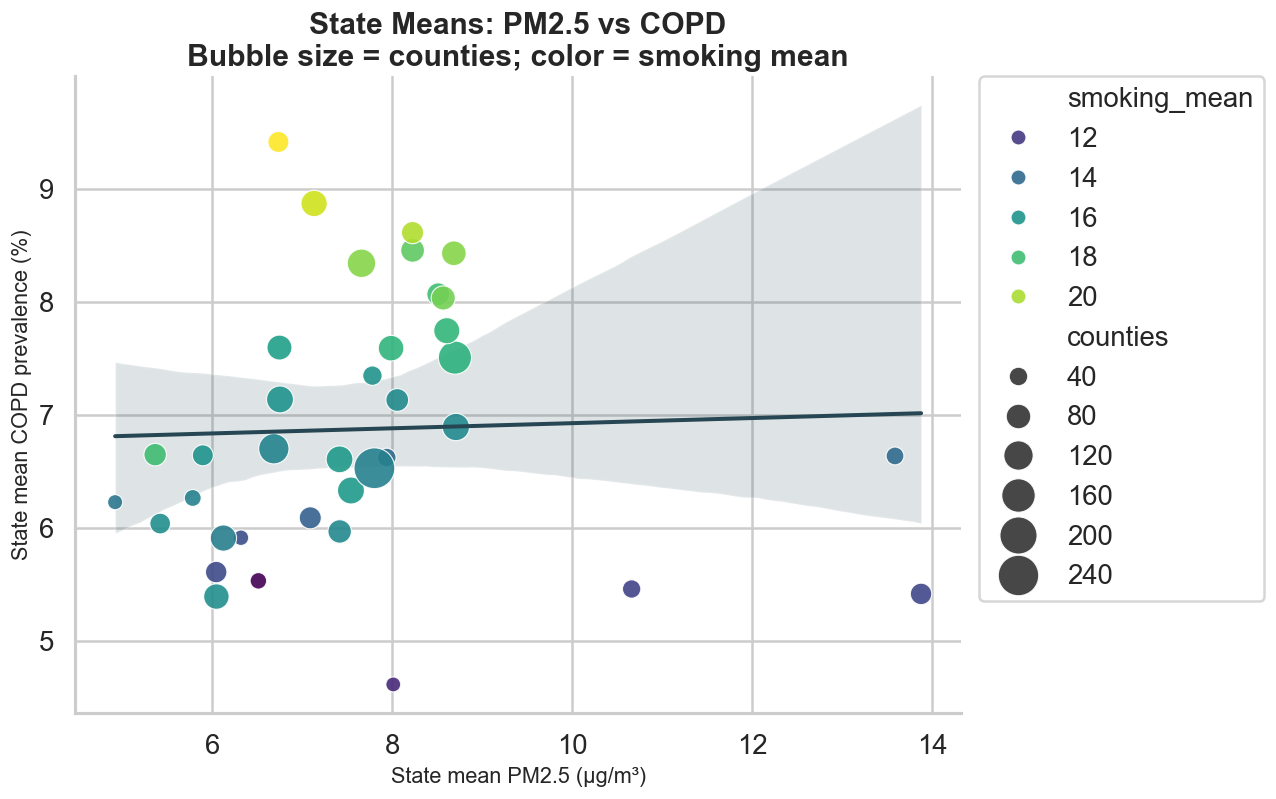

,StateAbbr,counties,pm25_mean,copd_mean,asthma_mean,smoking_mean
4,CA,58,13.876,5.416,9.981,12.578
35,OR,36,13.586,6.636,12.247,14.031
44,WA,39,10.659,5.459,11.290,12.413
13,IL,102,8.706,6.892,10.511,15.496
9,GA,157,8.695,7.506,10.625,17.419
23,MS,81,8.683,8.430,10.343,19.406
14,IN,92,8.604,7.745,11.334,17.615
34,OK,77,8.565,8.034,11.765,19.099
1,AL,67,8.509,8.067,10.584,18.009
2,AR,74,8.224,8.455,10.696,18.645


In [9]:
state_summary = (
    analysis_complete
    .groupby('StateAbbr', observed=True)
    .agg(
        counties=('fips', 'nunique'),
        pm25_mean=('pm25', 'mean'),
        copd_mean=('copd', 'mean'),
        asthma_mean=('asthma', 'mean'),
        smoking_mean=('smoking', 'mean')
    )
    .reset_index()
)

state_summary = state_summary.query('counties >= 20').copy()

plt.figure(figsize=(11, 7))
sns.regplot(
    data=state_summary,
    x='pm25_mean',
    y='copd_mean',
    scatter=False,
    color='#264653',
    line_kws={'linewidth': 2.4}
)

sns.scatterplot(
    data=state_summary,
    x='pm25_mean',
    y='copd_mean',
    size='counties',
    hue='smoking_mean',
    palette='viridis',
    sizes=(80, 600),
    edgecolor='white',
    linewidth=0.7,
    alpha=0.9,
)

plt.title('State Means: PM2.5 vs COPD\nBubble size = counties; color = smoking mean')
plt.xlabel('State mean PM2.5 (µg/m³)')
plt.ylabel('State mean COPD prevalence (%)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

display(state_summary.sort_values('pm25_mean', ascending=False).head(10).round(3))

At the state level, higher mean PM2.5 often co-occurs with higher mean COPD, but the spread remains substantial. Variation in bubble color suggests that between-state smoking differences may explain part of the observed respiratory burden differences. This motivates richer county-level modeling in the final project, including additional socioeconomic and demographic covariates and careful interpretation of ecological effects.


#### EDA Summary

Overall, this EDA suggests that PM2.5 has meaningful geographic variation, but unadjusted county-level PM2.5 associations are weak, especially for asthma. Smoking is the strongest respiratory correlate in the current dataset and materially changes PM2.5 estimates when included in models. The combined evidence supports moving to a more comprehensive multivariable framework in the final project, with explicit control for confounding and conservative interpretation of non-causal ecological relationships.


## Ethics

### A. Data Collection
 - [] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?
> We considered that not every county has the same number of air quality monitoring stations during data collection. This could introduce bias because there are fewer PM2.5 monitoring stations in rural areas and more in urban areas.
 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?
> Both EPA monitoring stations and the CDC collect county level data that does not include personal identifying information, such as names or precise addresses, so the privacy risk is extremely low.
 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?
> To mitigate potential downstream biases, we considered incorporating a range of protective variables, such as race, income, and education level, rather than focusing solely on PM2.5 concentrations. In this way, we identified potential environmental injustices, reflecting the distribution of polluting infrastructure across different communities in the United States.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?
> Although the raw data is publicly available, our data cleaning and tables are securely stored in a private Github repository, accessible only to team members and relevant faculty. Furthermore, by using Git, we can track who modified the data. This not only ensures data security during the analysis process but also prevents data from being corrupted.
 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?
>Our data will only be used during the project period in the Winter 2026 quarter, and will be deleted or archived after the grading is completed.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?
> Our analysis focuses primarily on outdoor PM2.5 concentrations, but our county level environmental data cannot capture factors affecting indoor air quality, such as household dust or workplace secondhand smoke, which contribute to chronic obstructive pulmonary disease and asthma.
 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?
> We identified detection bias, meaning that not being diagnosed by a doctor doesn't necessarily mean not being sick. In counties with limited access to healthcare, despite people being exposed to high concentrations of PM2.5, the diagnosis rate of respiratory diseases is low, leading to data that falsely suggests that poorer counties are healthier than they actually are. To address this detection bias, we will incorporate income as a factor to adjust these underestimated figures back to their true levels.
 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?
> In this project, to ensure that our charts and statistics accurately reflect the data, we will maintain integrity by avoiding misleading presentations, including outliers, and avoiding truncated axes, etc.
 - [ ] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?
> Our analysis is fully documented in Jupyter Notebooks, and the use of Git ensures that all modifications are recorded. Furthermore, we have listed all data sources to facilitate verification by the TA and ensure the reproducibility of our work.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?
> We understand that the variable of income might be misinterpreted as being linked to discrimination, but in our project, it is simply a factual statement reflecting the unfairness of social structures, and not intended to discriminate against any particular group.
 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
> We will test whether the model performs as accurately in impoverished counties as it does in wealthy counties. If the model makes more errors in impoverished areas, we will honestly report this in our report and explain the reasons.
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?
> We will use various metrics to evaluate the model. For example, we will look at R² to understand the extent of air pollution's impact on asthma.
 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
> Linear regression clearly shows the meaning of each number, which makes it easy to explain, for example, how much the asthma rate changes when PM2.5 levels increase.
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?
> We will include a "Limitations" section in the project and honestly state that this analysis primarily focuses on the relationship between air pollution and respiratory health, but does not consider other factors such as family genetics.
### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
> Our results are based on past data, so we would like to remind viewers that this data may need to be updated if future air pollution patterns change.
 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
> If we find that our analysis might mislead others, we will immediately update the content. We will also include a disclaimer stating that this is a school project and does not constitute any medical advice or policy recommendations.
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
> We use Git to manage our projects, and if we find any incorrect analysis or faulty code, we immediately go back to the appropriate version.
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?
> To prevent unintended use, we will add a disclaimer explaining that our project only shows correlation, not causation. In other words, for example, the fact that there are more cases of asthma in areas with poor air quality does not mean that poor air quality causes asthma.

## Team Expectations

* *Team Expectation 1* : We will use WeChat as our main channel (and email for formal messages). We respond within 24 hours on weekdays (and will send a quick acknowledgement + ETA if we’re busy).
* *Team Expectation 2* : We will meet at least once per week (virtually on WeChat) for progress updates and planning. Each member will come prepared with: what they completed, what they’re doing next, and any blockers.
* *Team Expecation 3* : All work will be tracked in a shared task list. Each task has a clear owner, deliverable, and deadline, and we update progress regularly so everyone can see what’s happening.
* *Team Expecation 4* : We will divide work evenly by effort, and ensure everyone contributes to (1) defining/refining the research question + dataset choice, (2) coding/analysis, (3) writing explanations, and (4) editing/review—not just one person doing all the coding or writing.
* *Team Expecation 5* : If a member is struggling to deliver, they will notify the group as soon as possible (ideally 48+ hours before a deadline). The team will respond by pairing up, adjusting scope, or redistributing tasks early rather than waiting until the last minute.
* *Team Expecation 6* : We will communicate respectfully using “I” statements and specific feedback (e.g., “I think X is an issue because Y—what do you think?”). If conflict persists, we will discuss it in a meeting, agree on a concrete plan, and follow up at the next check-in.

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/7  |  1 PM | Read over project proposal and understand individual roles  | Perform data wrangling together to see the general picture and split individual sections to clean&visualize | 
| 2/14  |  1 PM |  Complete individual data wrangling | Discuss possible analytic approaches and methods, Assign group members to lead each specific part | 
| 2/18  |  11 PM |  Complete DataCheckpoint 1 | Discuss possible analytic approaches and methods, Assign group members to lead each specific part | 
| 2/21  | 1 PM  | Complete first-stage analysis  | Check for any disputes/inconsistencies among each analysis and data wrangling |
| 2/28  | 1 PM  | Complete second-stage analysis | Group the work for write-up and visualization |
| 3/7  | 1 PM  | Complete most write-ups&visualization | Discuss/edit full project |
| 3/14  | 1 PM  | Ready to present/submit| Final progress-check |